In [1]:
# %matplotlib widget
%matplotlib qt

In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections, re
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

In [3]:
data = pd.read_csv("final_defesas_2006a2024.csv")
data_filiacao = pd.read_csv("csvs/filiacao.csv")
data_genero = pd.read_csv("csvs/genero2.csv")
data_dpt = pd.read_csv("csvs/departamento.csv")

## Criação de nós

In [4]:
padrao_avaliadores = 'avaliador\d$'
avaliadores = [col for col in data.columns if re.search(padrao_avaliadores, col)]
avaliadores.append("orientador")

In [5]:
uni_key = {uni:key for key, uni in enumerate(data_filiacao["filiacao padronizada"].unique())}

In [6]:
css4_colors = list(mcolors.CSS4_COLORS.keys())

# You can use the first 130 of these colors
palette_130 = css4_colors[:data_filiacao["filiacao padronizada"].unique().shape[0]]

In [7]:
grafo_defesas = nx.MultiDiGraph()
# grafo_defesas = nx.DiGraph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        if data_dpt[data_dpt["orcid"]==url.split("/")[-1]].shape[0] == 0:
            dpt = None
        else:
            dpt = data_dpt[data_dpt["orcid"]==url.split("/")[-1]]["dpt"].values[0]
        grafo_defesas.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]] if filiacao!=filiacao_alvo else "yellowgreen",
                            dpt=dpt
                            )
    n_banca -=- 1

In [8]:
grafo_defesas.nodes["0000-0002-8803-0401"]

{'nome': 'Rodolfo Azevedo',
 'filiacao': 'Universidade Estadual de Campinas',
 'genero': 'Masculino',
 'filiacao_genero': 'Masculino_interno',
 'bipartite': 0,
 'marker': 'M',
 'cor_bin': 'red',
 'cor': 'yellowgreen',
 'dpt': None}

## Criação de arestas (arestas representam colaborações em defesas de mestrado, mestrado profissional ou doutorado)

In [9]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        # if grafo_defesas.has_edge(orcid_orient, orcid_aval):
        #     grafo_defesas[orcid_orient][orcid_aval][0]["weight"] -=- 1
        #     continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"])
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [9]:
filiacao_alvo = "Universidade Estadual de Campinas"
dict_ano = nx.get_edge_attributes(grafo_defesas, name="ano")
df_dict = collections.defaultdict(list)
for person1, person2, infos in grafo_defesas.edges(data=True):
    node1 = grafo_defesas.nodes[person1]
    node2 = grafo_defesas.nodes[person2]
    df_dict["orient_filiacao_bin"].append("Unicamp" if node1['filiacao'] == filiacao_alvo else "Externa/o")
    df_dict["aval_filiacao_bin"].append("Unicamp" if node2['filiacao'] == filiacao_alvo else "Externa/o")
    df_dict["orient_genero"].append(node1["genero"])
    df_dict["aval_genero"].append(node2["genero"])
    df_dict["ano_defesa"].append(infos["ano"])
    df_dict["tipo_defesa"].append(infos["tipo"])
    # break
df = pd.DataFrame(df_dict)

<Axes: xlabel='count', ylabel='aval_filiacao_bin'>

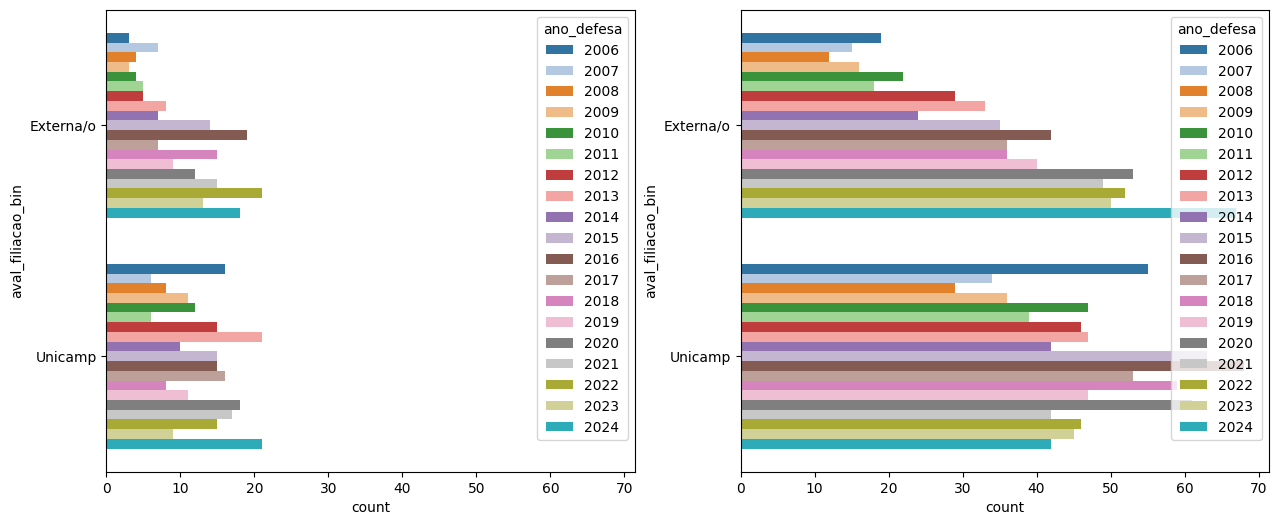

In [26]:
fig, ax = plt.subplots(ncols=2, figsize=(15,6), sharex=True)

sns.countplot(df[df["aval_genero"] == "Feminino"], y="aval_filiacao_bin", hue="ano_defesa", ax=ax[0], order=("Externa/o", "Unicamp"), palette="tab20")
sns.countplot(df[df["aval_genero"] == "Masculino"], y="aval_filiacao_bin", hue="ano_defesa", ax=ax[1], order=("Externa/o", "Unicamp"), palette="tab20")

<Axes: xlabel='count', ylabel='aval_filiacao_bin'>

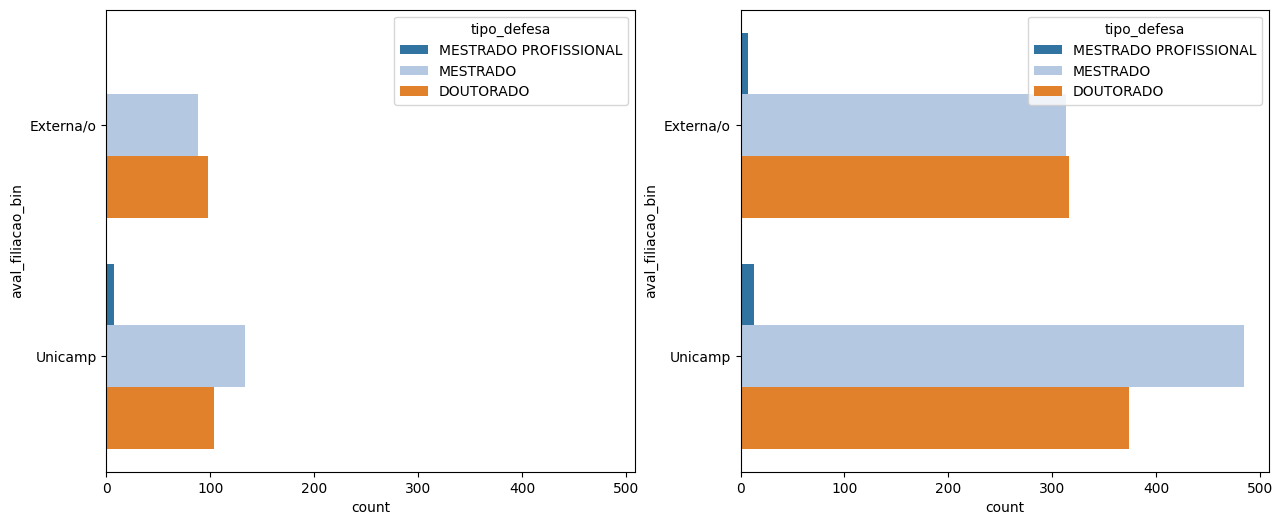

In [65]:
fig, ax = plt.subplots(ncols=2, figsize=(15,6), sharex=True)
hue_order = ["MESTRADO PROFISSIONAL", "MESTRADO", "DOUTORADO"]
sns.countplot(df[df["aval_genero"] == "Feminino"], y="aval_filiacao_bin", hue="tipo_defesa", ax=ax[0], order=("Externa/o", "Unicamp"),
              palette="tab20", hue_order=hue_order)
sns.countplot(df[df["aval_genero"] == "Masculino"], y="aval_filiacao_bin", hue="tipo_defesa", ax=ax[1], order=("Externa/o", "Unicamp"),
              palette="tab20", hue_order=hue_order)

<Axes: xlabel='count', ylabel='aval_filiacao_bin'>

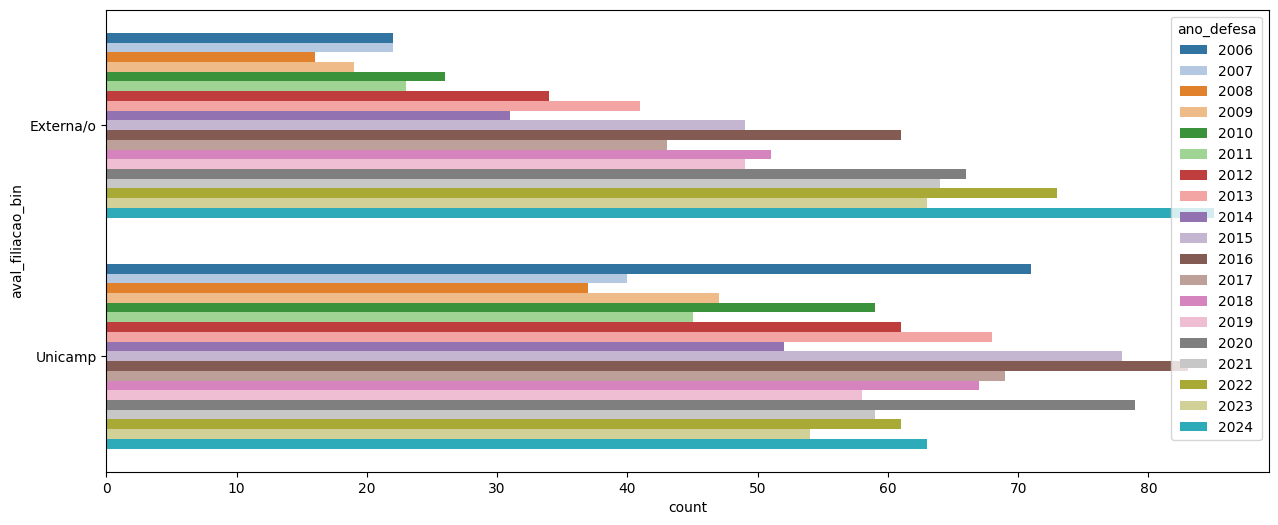

In [58]:
fig, ax = plt.subplots(ncols=1, figsize=(15,6), sharex=True)

sns.countplot(df, y="aval_filiacao_bin", hue="ano_defesa", ax=ax, order=("Externa/o", "Unicamp"), palette="tab20")

In [25]:
dict_ano = nx.get_edge_attributes(grafo_defesas, name="ano")

In [10]:
pos = nx.drawing.nx_pydot.graphviz_layout(grafo_defesas, prog="twopi")

In [43]:
xlim_max, ylim_max = np.array([[p1, p2] for p1, p2 in pos.values()]).max(axis=0)
xlim_min, ylim_min = np.array([[p1, p2] for p1, p2 in pos.values()]).min(axis=0)

In [12]:
ano = 2006
edge_ano = []
nos_w_edge_ano = []
k_ano = []
pesos_arestas = collections.defaultdict(lambda:1.)
cores=collections.defaultdict(int)
marcadores=collections.defaultdict(str)
cores_bin=collections.defaultdict(int)
pesos = collections.defaultdict(lambda: 150)
cores_arestas = collections.defaultdict(lambda:"black")
scale=1
for ano in range(2006, 2025):

    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        edge_ano.append((person1, person2))
        pesos_arestas[(person1, person2)]-=-.1
        pesos[person1]-=-50
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]

    node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

    node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

    fig, ax = plt.subplots(ncols=1, figsize=(50,25), dpi=200)
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        #    node_color=node_color_F, node_size=np.array(node_size_F),node_shape="$F$")
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
    _ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed", alpha=0.4,
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])
    # ax.set_ylim(ylim_min*(1/scale), ylim_max*scale)
    # ax.set_xlim(xlim_min*(1/scale), xlim_max*scale)
    ax.set_title(f"Ano: {ano}", fontsize=20)
    fig.savefig(f"images/evolucao_{ano}_pydot.png", bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    # if ano == 2010: break

In [ ]:
#### EVOLUCAO PESSOA ESPECÍFICA

ano = 2006
edge_ano = []
nos_w_edge_ano = []
k_ano = []
pessoa_alvo = "Joao Meidanis"
pesos_arestas = collections.defaultdict(lambda:1.)
cores=collections.defaultdict(int)
marcadores=collections.defaultdict(str)
cores_bin=collections.defaultdict(int)
pesos = collections.defaultdict(lambda: 150)
cores_arestas = collections.defaultdict(lambda:"black")
scale=1
pessoa_alvo_convite = {}
for ano in range(2006, 2025):

    for person1, person2, infos in grafo_defesas.edges(data=True):
        
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        
        if node1["nome"] != pessoa_alvo: continue
        # elif node1["nome"] != pessoa_alvo and node2["nome"]!=pessoa_alvo: continue
        
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        edge_ano.append((person1, person2))
        pesos_arestas[(person1, person2)]-=-.5
        pesos[person1]-=-50
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]
        pessoa_alvo_convite[node1["orcid"]]

    node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

    node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

    fig, ax = plt.subplots(ncols=1, figsize=(48,25), dpi=200)
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        #    node_color=node_color_F, node_size=np.array(node_size_F),node_shape="$F$")
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    
    nx.draw_networkx_labels(grafo_defesas, pos=pos, labels={"0000-0001-7878-4990": pessoa_alvo})
    # nx.draw_networkx_labels(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
    #                     node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
    _ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed", alpha=0.4,
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])
    # ax.set_ylim(ylim_min*(1/scale), ylim_max*scale)
    # ax.set_xlim(xlim_min*(1/scale), xlim_max*scale)
    ax.set_title(f"Ano: {ano}", fontsize=20)
    fig.savefig(f"images/evolucao_{pessoa_alvo}_{ano}_pydot.png", bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    # if ano == 2010: break

In [ ]:
node1

{'nome': 'BULGARELI, J V',
 'filiacao': 'Universidade Federal de Uberlândia',
 'genero': 'Feminino',
 'filiacao_genero': 'Feminino_externo',
 'bipartite': 1,
 'marker': 'F',
 'cor_bin': 'blue',
 'cor': 'maroon'}

In [70]:
ano = 2006
edge_ano = []
nos_w_edge_ano = []
k_ano = []
filiacao_alvo = "Universidade Estadual de Campinas"
pesos_arestas = collections.defaultdict(lambda:1.)
cores=collections.defaultdict(int)
marcadores=collections.defaultdict(str)
cores_bin=collections.defaultdict(int)
pesos = collections.defaultdict(lambda: 600)
cores_arestas = collections.defaultdict(lambda:"fuchsia")
scale=1
for ano in range(2006, 2025):

    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["filiacao"] == node2["filiacao"]:
            cores_arestas[(person1, person2)] = "darkgray"
            # else:
            #     cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        edge_ano.append((person1, person2))
        pesos_arestas[(person1, person2)]-=-.2
        pesos[person1]=100
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]

    node_color_F = [cores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

    node_color_M = [cores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_size=100
    fig, ax = plt.subplots(ncols=1, figsize=(30,30))
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    _ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed", alpha=0.4,
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])
    # ax.set_ylim(ylim_min*(1/scale), ylim_max*scale)
    # ax.set_xlim(xlim_min*(1/scale), xlim_max*scale)
    ax.set_title(f"Ano: {ano}", fontsize=20)
    fig.savefig(f"images/evolucao_{ano}_pydot_IES.png", bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    # if ano == 2010: break

In [31]:
ano = 2006

scale=1
for ano in range(2006, 2025):
    edge_ano = []
    nos_w_edge_ano = []
    k_ano = []
    pesos_arestas = collections.defaultdict(lambda:1.)
    cores=collections.defaultdict(int)
    marcadores=collections.defaultdict(str)
    cores_bin=collections.defaultdict(int)
    pesos = collections.defaultdict(lambda: 150)
    cores_arestas = collections.defaultdict(lambda:"black")
    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        edge_ano.append((person1, person2))
        pesos_arestas[(person1, person2)]-=-.1
        pesos[person1]-=-50
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]

    node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

    node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

    fig, ax = plt.subplots(ncols=1, figsize=(30,30))
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        #    node_color=node_color_F, node_size=np.array(node_size_F),node_shape="$F$")
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
    _ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed", alpha=0.4,
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])
    # ax.set_ylim(ylim_min*(1/scale), ylim_max*scale)
    # ax.set_xlim(xlim_min*(1/scale), xlim_max*scale)
    ax.set_title(f"Ano: {ano}", fontsize=20)
    fig.savefig(f"images/evolucao_semacumular_{ano}_pydot.png", bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    # if ano == 2010: break

In [11]:
ano = 2006
edge_ano = []
nos_w_edge_ano = []
k_ano = []
pesos_arestas = collections.defaultdict(lambda:1.)
cores=collections.defaultdict(int)
marcadores=collections.defaultdict(str)
cores_bin=collections.defaultdict(int)
pesos = collections.defaultdict(lambda: 150)
cores_arestas = collections.defaultdict(lambda:"black")
scale=1.25
for ano in range(2006, 2025):

    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        edge_ano.append((person1, person2))
        pesos_arestas[(person1, person2)]-=-.1
        pesos[person1]-=-10
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]

node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

node_sizes = node_size_F+node_size_M
node_shapes = node_shape_F+node_shape_M

fig, ax = plt.subplots(ncols=1, figsize=(40,20))
_ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed",
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)], alpha=0.5,
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])
col1 = nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)

col2 = nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)

## show on hover
node_collections = [col1, col2]
nodes_list  = [[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
               [node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"]]

xy_all = []
node_all = []
col_index = []
for idx, (col, nlist) in enumerate(zip(node_collections, nodes_list)):
    xy = col.get_offsets()
    xy_all.append(xy)
    node_all.extend(nlist)
    col_index.extend([idx] * len(nlist))
xy_all = np.vstack(xy_all)

edge_coords = []
edges = list(grafo_defesas.edges())
for u, v in edges:
    tam_u, tam_v = pesos[u], pesos[v]
    edge_coords.append([np.array(pos[u]), np.array(pos[v])])
edge_collection = LineCollection(
    edge_coords,
    colors="gray",
    linewidths=1.0,
    alpha=0,
    zorder=1,
    picker=True   # <-- necessary for clickable edges
)
ax.add_collection(edge_collection)

# --- Edge highlight collection (empty at start) ---
edge_highlight = LineCollection(
    [],
    colors="cyan",
    linewidths=3.0,
    zorder=5
)
ax.add_collection(edge_highlight)
edge_highlight.set_visible(False)

annot = ax.annotate(
    "", xy=(0, 0), xycoords="data", textcoords="offset points",
    xytext=(10, 10), ha="left",
    bbox=dict(boxstyle="round", fc="lightyellow", ec="gray")
)
annot.set_visible(False)
highlight = ax.scatter([], [], s=600, facecolor="none", edgecolors="cyan", linewidth=2, zorder=5)
highlight.set_visible(False)
highlighted_nodes = []
highlight_artists = []
annot_artists = []
# def update_annot(i):
#     node = node_all[i]
#     annot.xy = xy_all[i]
#     data = grafo_defesas.nodes[node]
#     highlight.set_offsets([xy_all[i]])
#     highlight.set_sizes([node_sizes[i]])
#     # highlight.set_marker(node_shapes[i])
#     highlight.set_visible(True)
#     annot.set_text(f"Node {node}\nNone: {data['nome']}\nIES: {data['filiacao']}")
#     annot.set_visible(True)
def add_highlight(i):
    """Create a highlight scatter for node i."""
    xy = xy_all[i]
    size = node_sizes[i]

    hl = ax.scatter(
        [xy[0]], [xy[1]],
        s=size,
        facecolor='none',
        edgecolors='cyan',
        linewidth=2,
        zorder=5,
    )
    highlight_artists.append(hl)


def add_annotation(i):
    """Create an independent annotation box for node i."""
    xy = xy_all[i]
    node = node_all[i]
    data = grafo_defesas.nodes[node]

    ann = ax.annotate(
        f"Node {node}\nNome: {data['nome']}\nIES: {data['filiacao']}",
        xy=xy,
        xycoords="data",
        xytext=(10, 10),
        textcoords="offset points",
        ha="left",
        bbox=dict(boxstyle="round", fc="lightyellow", ec="gray")
    )
    annot_artists.append(ann)
def update_annot(i):
    node = node_all[i]
    annot.xy = xy_all[i]
    data = grafo_defesas.nodes[node]
    annot.set_text(f"Node {node}\nNome: {data['nome']}\nIES: {data['filiacao']}")
    annot.set_visible(True)

def refresh_highlight():
    if not highlighted_nodes:
        highlight.set_visible(False)
        return
    
    coords = xy_all[highlighted_nodes]
    sizes = [node_sizes[i] for i in highlighted_nodes]

    highlight.set_offsets(coords)
    highlight.set_sizes(sizes)
    highlight.set_visible(True)

def on_click(event):
    # not inside the axis → clear
    if event.inaxes != ax:
        annot.set_visible(False)
        highlight.set_visible(False)
        edge_highlight.set_visible(False)
        fig.canvas.draw_idle()
        return
    # check node collections for hits
    # for col_idx_i, col in enumerate(node_collections):
    #     contains, ind = col.contains(event)
    #     if contains:
    #         local_i = ind["ind"][0]

    #         # Map (collection, local_index) → global index
    #         global_i = np.where(np.array(col_index) == col_idx_i)[0][local_i]

    #         update_annot(global_i)
    #         fig.canvas.draw_idle()
    #         return
    for col_idx_i, col in enumerate(node_collections):
        contains, ind = col.contains(event)
        if contains:
            local_i = ind["ind"][0]
            global_i = np.where(np.array(col_index) == col_idx_i)[0][local_i]

            if global_i not in highlighted_nodes:
                highlighted_nodes.append(global_i)
                add_highlight(global_i)
                add_annotation(global_i)

            fig.canvas.draw_idle()
            return
    contains, edge_info = edge_collection.contains(event)
    if contains:
        seg_index = edge_info["ind"][0]

        # set the selected edge as highlighted
        edge_highlight.set_segments([edge_coords[seg_index]])
        edge_highlight.set_visible(True)

        # annot.set_visible(False)
        # highlight.set_visible(False)
        fig.canvas.draw_idle()
        return
    # annot.set_visible(False)
    # highlight.set_visible(False)
    # edge_highlight.set_visible(False)
    # fig.canvas.draw_idle()
    highlighted_nodes.clear()

    # remove all highlight scatters
    for hl in highlight_artists:
        hl.remove()
    highlight_artists.clear()

    # remove all annotation boxes
    for ann in annot_artists:
        ann.remove()
    annot_artists.clear()

    edge_highlight.set_visible(False)
    fig.canvas.draw_idle()
    
# fig.canvas.mpl_connect("motion_notify_event", on_move)
fig.canvas.mpl_connect("button_press_event", on_click)
# fig.canvas.layout.width = "1000px"
# fig.canvas.layout.height = "1000px"
# ax.set_axis_off()
plt.show()

libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast
